# Visualisasi Evaluasi Algoritma Local Search
Notebook ini digunakan untuk memenuhi spesifikasi bonus, yaitu memvisualisasikan grafik penurunan nilai fungsi objektif (total waktu tunggu kendaraan) dari berbagai algoritma Local Search seiring berjalannya iterasi.

In [1]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../../src/local_search'))

from environment import GreenWaveEnvironment
from algorithms import LocalSearchAlgorithms
from main import GeneticAlgorithm

In [3]:
# 1. Inisialisasi Environment
env = GreenWaveEnvironment(num_intersections=20, cycle_time=90, green_duration=45)
search_algs = LocalSearchAlgorithms(env)
ga = GeneticAlgorithm(env, pop_size=50)

# 2. Eksekusi masing-masing algoritma
print("Menjalankan Steepest-Ascent Hill Climbing...")
_, _, _, _ = search_algs.steepest_ascent_hill_climbing(max_iter=150)
history_steepest = [cost for state, cost in search_algs.history]

print("Menjalankan Stochastic Hill Climbing...")
_, _, _, _ = search_algs.stochastic_hill_climbing(max_iter=150)
history_stoch = [cost for state, cost in search_algs.history]

print("Menjalankan Simulated Annealing...")
_, _, _, _ = search_algs.simulated_annealing(initial_temp=5000, cooling_rate=0.97, max_iter_per_temp=5)
history_sa = [cost for state, cost, temp in search_algs.history]

print("Menjalankan Genetic Algorithm...")
_, _, _, _ = ga.run(max_generations=150)
history_ga = [cost for state, cost in ga.history]

print("Seluruh algoritma selesai dieksekusi, data siap divisualisasikan!")

Menjalankan Steepest-Ascent Hill Climbing...
Menjalankan Stochastic Hill Climbing...
Menjalankan Simulated Annealing...
Menjalankan Genetic Algorithm...
Seluruh algoritma selesai dieksekusi, data siap divisualisasikan!


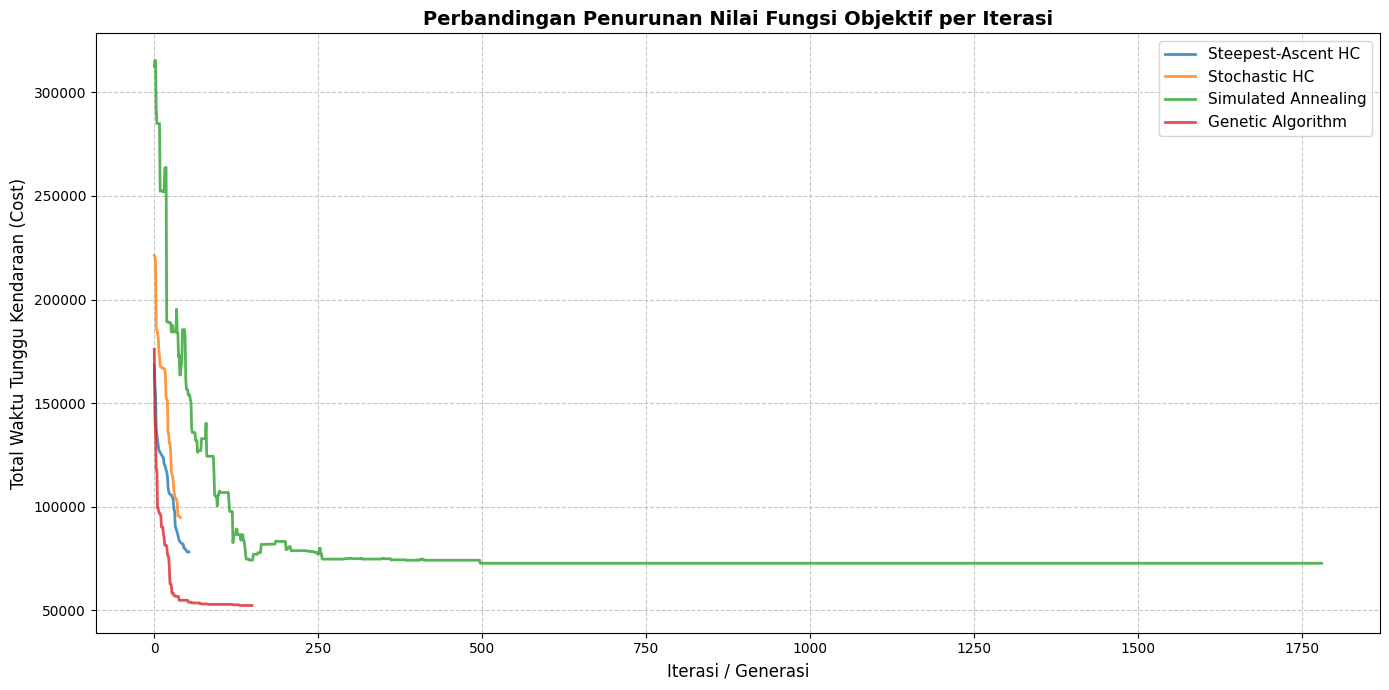

In [4]:
# 3. Plotting grafik perbandingan
plt.figure(figsize=(14, 7))

plt.plot(history_steepest, label='Steepest-Ascent HC', linewidth=2, alpha=0.8)
plt.plot(history_stoch, label='Stochastic HC', linewidth=2, alpha=0.8)
plt.plot(history_sa, label='Simulated Annealing', linewidth=2, alpha=0.8)
plt.plot(history_ga, label='Genetic Algorithm', linewidth=2, alpha=0.8)

plt.title('Perbandingan Penurunan Nilai Fungsi Objektif per Iterasi', fontsize=14, fontweight='bold')
plt.xlabel('Iterasi / Generasi', fontsize=12)
plt.ylabel('Total Waktu Tunggu Kendaraan (Cost)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()